## Advanced Functionality of music21

In this notebook we explore some of the more advanced analytical features available in music21. Beyond basic score parsing and note manipulation, music21 provides an abundance of tools for carrying out various modes of analysis and transformations directly in Python.

We will focus on four main areas:

1) **Intervals** – Creating, measuring, and using intervals to transpose notes, chords and streams.

2) **Roman Numerals** – Analysing chords within a key using tonal harmonic theory.

3) **Harmonic Function Analysis** – Classifying chords as tonic, predominant, or dominant.

4) **Neo-Riemannian Analysis** – Exploring transformational relationships between triads using L, P, and R operations.


We base much of the material in this notebook on the excellent [user guide](https://music21.org/music21docs/usersGuide/index.html) and [module reference](https://music21.org/music21docs/moduleReference/index.html) available on the music21 website. We encourage you to check these out if you wish to further explore some of the areas introduced here.

## Imports and Data Setup

In [140]:
from pathlib import Path

from music21 import converter, interval, note, stream, chord, key, roman, corpus, analysis, chord
import jams
from harte.harte import Harte

In [66]:
DATA_PATH = Path("../data")
JAMS_PATH = DATA_PATH / "jams"
JSON_PATH = DATA_PATH / "json"

## Intervals

[Intervals](https://music21.org/music21docs/usersGuide/usersGuide_18_intervals.html) are a key class in music21 that represent the distance in pitch space between two notes. Here we will highlight some of its useful functionalities particularly in relation to manipulating chords.

First, let's have a look at some basics. Creating an interval and inspecting its attributes.

In [60]:
from music21 import interval

i = interval.Interval('M3') # 'M3' is the abbreviated string for 'Major Third'
i

<music21.interval.Interval M3>

In [61]:
(i.niceName, i.semitones, i.intervalClass, i.isConsonant())

('Major Third', 4, 4, True)

We can create an interval from two notes. music21 will then compute the interval automatically.

In [62]:
from music21 import note

n1 = note.Note('C4')
n2 = note.Note('G4')

p5 = interval.Interval(n1, n2)
p5.niceName

'Perfect Fifth'

We can also use intervals for transposition for pitch, note, chord and stream objects. We demonstrate a simple example for both chord and stream objects below.

In [151]:
# Transposing a chord with an interval
i = interval.Interval('P5')

c = chord.Chord('F A C')
c.show('text')

c.transpose(i, inPlace=True)
c.show('text')

<music21.chord.Chord F A C>
<music21.chord.Chord C E G>


Original stream:


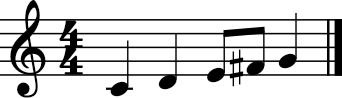

Transposed stream:


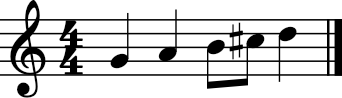

In [152]:
# Transposing a stream with an interval
s = converter.parse('tinyNotation: 4/4 c4 d e8 f# g4')
print("Original stream:")
s.show()
s2 = s.transpose(i)
print("Transposed stream:")
s2.show()

Next, let's load a JAMS file and see if we can modify one of the chords with an interval.

In [105]:
# allow JAMS to recognize the time signature namespace as we did in the previous session
jams.schema.add_namespace(str(JSON_PATH / "timesig.json"))

file_name = JAMS_PATH / "biab-internet-corpus_2.jams"

jam = jams.load(str(file_name), validate=False)

<music21.chord.Chord A4 C#5 E5>


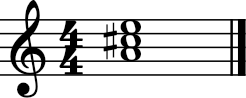

Chord label: A:maj
Chord isSeventh:  False


In [156]:
# get the first annotation of type "chord"
chords = jam.annotations[0].data

# get the first chord annotation
first_chord = chords[0]
label = first_chord.value

# parse the chord label into a music21 chord object
harte_chord = Harte(label)
pitches = harte_chord.pitches
music21_chord = chord.Chord(pitches, quarterLength=float(first_chord.duration))

music21_chord.show('text')
music21_chord.show()
print("Chord label:", label)
print("Chord isSeventh: ", music21_chord.isSeventh())

Create an interval that is a 7th above the root in order to create a dominant 7th chord.

<music21.chord.Chord A4 C#5 E5 G5>


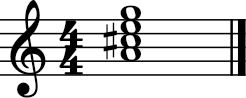

Chord isSeventh:  True


In [157]:
root_pitch = music21_chord.root()

m7 = interval.Interval('m7')

seventh_pitch = m7.transposePitch(root_pitch)

music21_chord.add(seventh_pitch)
music21_chord

music21_chord.show('text')
music21_chord.show()
print("Chord isSeventh: ", music21_chord.isSeventh())

## Roman Numerals

music21 supports [roman numeral analysis](https://music21.org/music21docs/usersGuide/usersGuide_23_romanNumerals.html). The `RomanNumeral` object is a subclass of the chord object. In tonal music, a chord’s meaning depends on its key context. Roman numeral analysis captures this by labeling chords according to their scale degree and function within a key. 

We will demonstrate this below by initialising the same chord in three different keys.

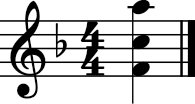

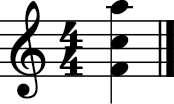

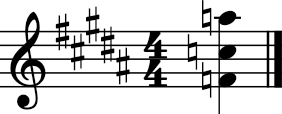

(<music21.roman.RomanNumeral I in F major>,
 <music21.roman.RomanNumeral IV in C major>,
 <music21.roman.RomanNumeral bV in B major>)

In [8]:
f = chord.Chord('F4 C5 A5')

kf = key.Key('F')
kc = key.Key('C')
kb = key.Key('B')

sb = stream.Part([kf, f])
sb.show()

sb = stream.Part([kc, f])
sb.show()

sb = stream.Part([kb, f])
sb.show()

rf = roman.romanNumeralFromChord(f, kf)
rc = roman.romanNumeralFromChord(f, kc)
rb = roman.romanNumeralFromChord(f, kb)


rf, rc, rb

Some `RomanNumerals` make more sense than others, so there’s a .functionalityScore which returns a number from 0 to 100 as a rough approximation of how “functional” this chord is:

In [9]:
(rf.functionalityScore, rc.functionalityScore, rb.functionalityScore)

(100, 59, 0)

Below are some other useful attributes for `RomanNumeral` objects.

In [12]:
(rf.figure, rc.figure, rb.figure)

('I', 'IV', 'bV')

In [13]:
rf.figureAndKey

'I in F major'

In [15]:
(rf.romanNumeralAlone, rc.romanNumeralAlone, rb.romanNumeralAlone)

('I', 'IV', 'V')

Finally, you can create `RomanNumerals` directly from strings. Notice that when you create it directly, the chord is created in a closed position.

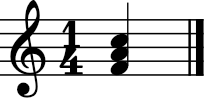

In [18]:
roman.RomanNumeral('IV7', 'B-')
roman.RomanNumeral('ii65', 'E')


rf2 = roman.RomanNumeral('I', 'F')
rf2.show()


## Harmonic Function Analysis

`harmonicFunction` in the analysis module of music21 provides a mapping between Roman numeral figures and harmonic function labels.

We can start with a simple toy example and create a simple progression with roman numerals, making use of the `RomanNumeral` class we saw earlier.

In [8]:
k = key.Key('C')

progression_figures = ['I', 'vi', 'ii', 'V7', 'I']

roman_numerals = [roman.RomanNumeral(fig, k) for fig in progression_figures]

roman_numerals


[<music21.roman.RomanNumeral I in C major>,
 <music21.roman.RomanNumeral vi in C major>,
 <music21.roman.RomanNumeral ii in C major>,
 <music21.roman.RomanNumeral V7 in C major>,
 <music21.roman.RomanNumeral I in C major>]

Then we can use `harmonicFunction` from the analysis module to take a Roman numeral and return its corresponding harmonic function label.

In [10]:
from music21.analysis import harmonicFunction
for rn in roman_numerals:
    fn = harmonicFunction.romanToFunction(rn)
    print(f"{rn.figure:3}  →  {str(fn)}")

I    →  T
vi   →  Tp
ii   →  Sp
V7   →  D
I    →  T


Let's try it now with a real score, below we load a four-part Bach chorale and get the key.

In [25]:
score = corpus.parse('bach/bwv66.6')
print(score)
key_estimate = score.analyze('key')
print("Estimated Key:", key_estimate)

<music21.stream.Score bach/bwv66.6.mxl>
Estimated Key: f# minor


Lets extract roman numerals from the chords in the score. Because the Bach chorale is polyphonic (multiple independent voices), we use `chordify()` to collapse all simultaneous notes into single Chord objects. This produces a reduction of the score, allowing us to apply `romanNumeralFromChord()`, which requires a chord as input.

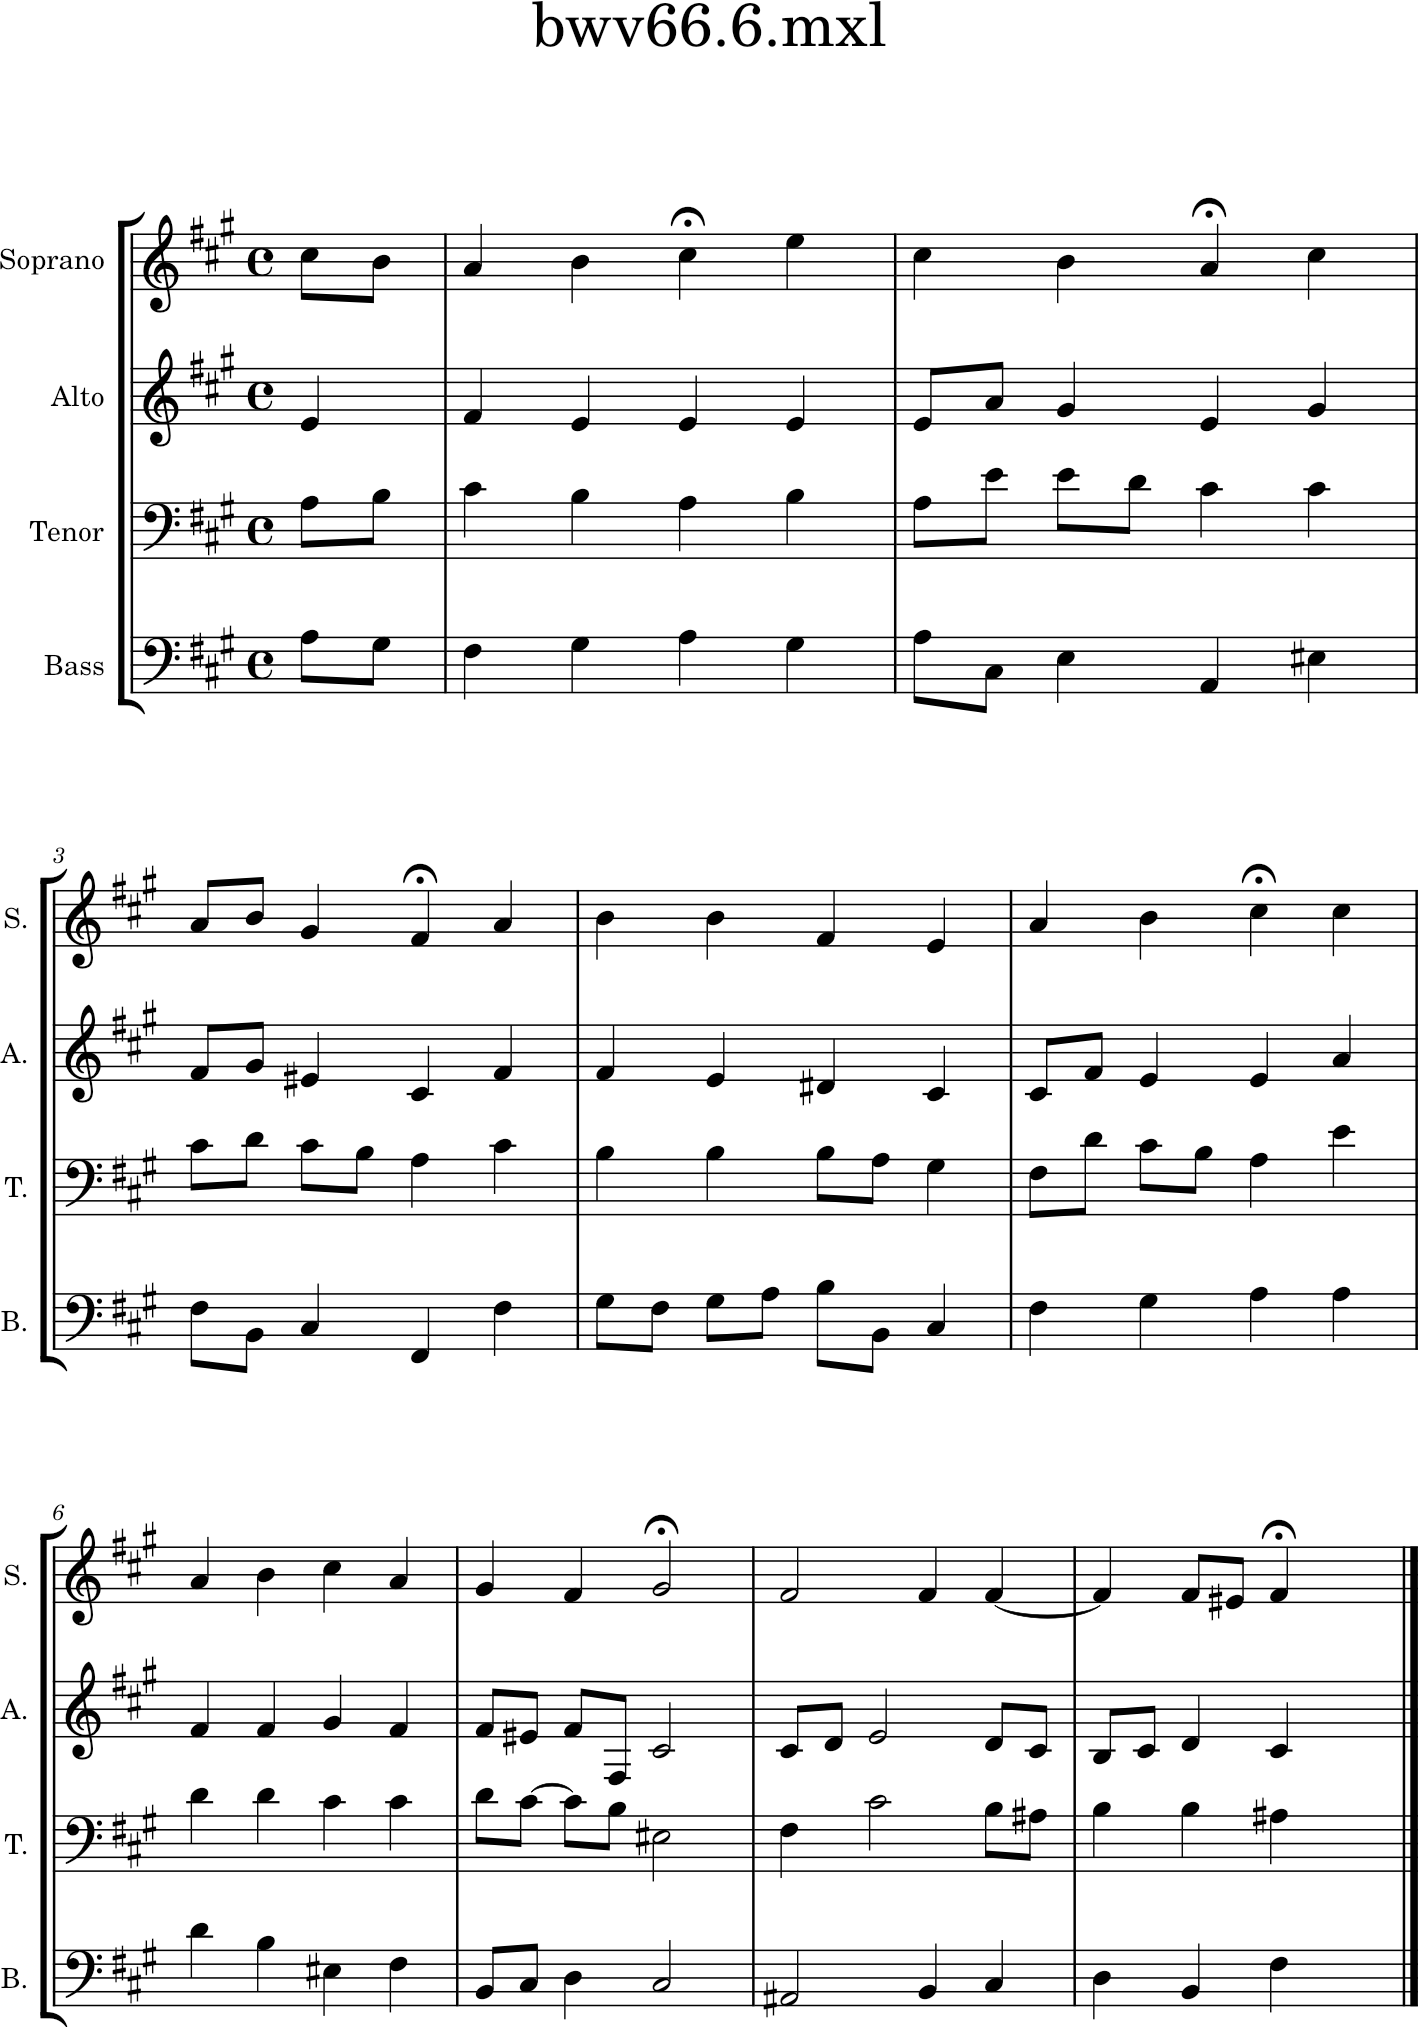

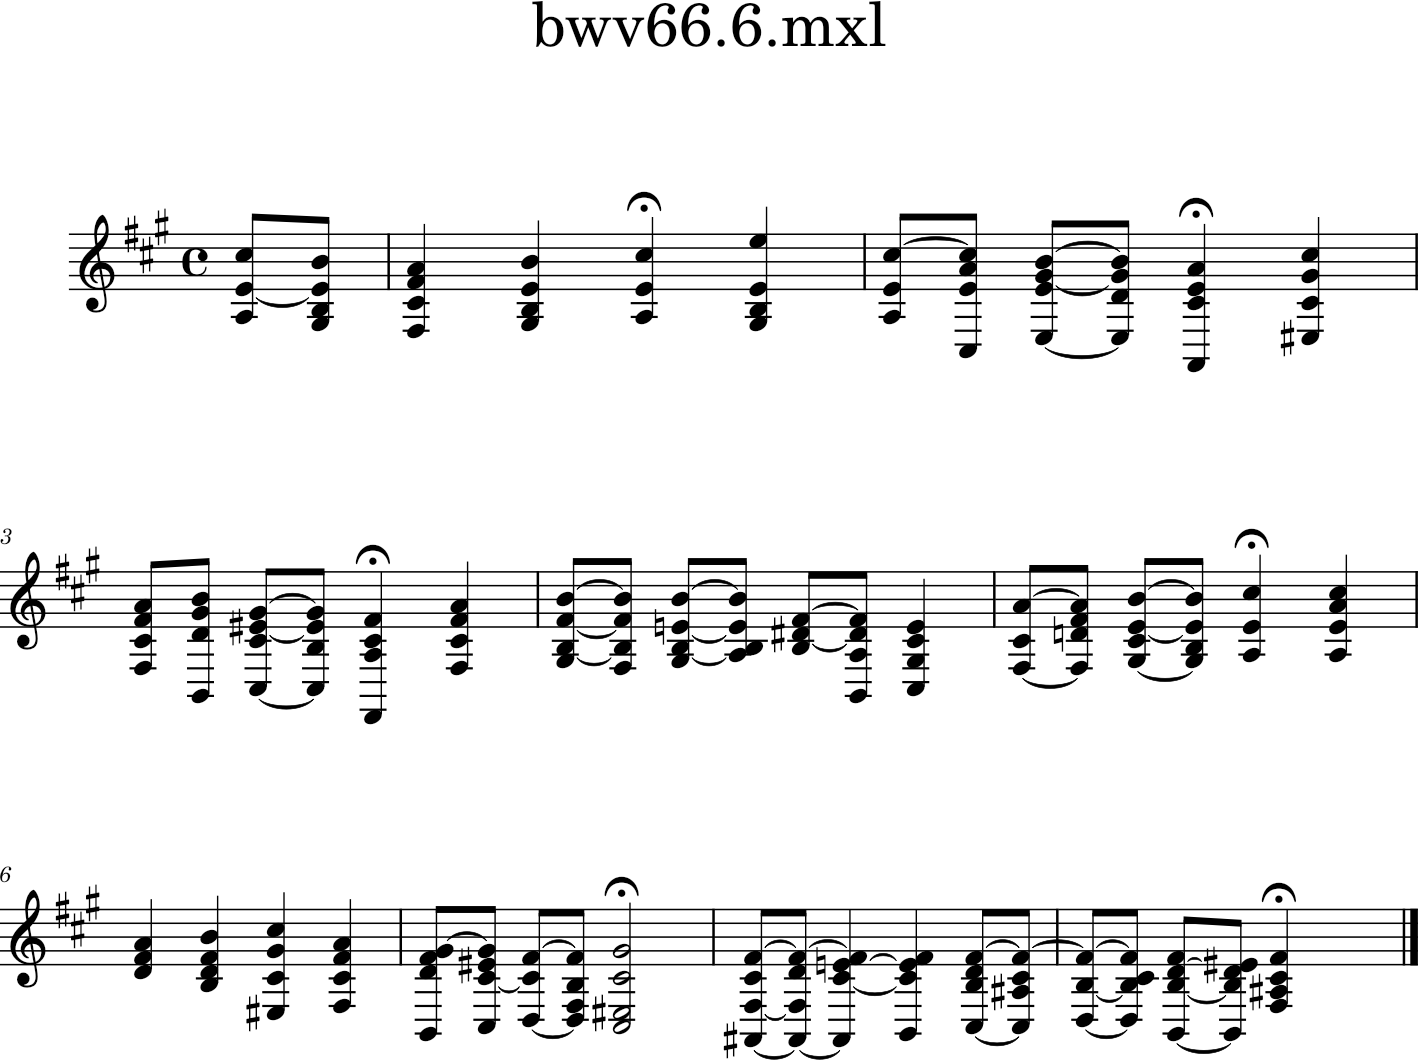

In [ ]:
# have a look at the score before and after chordifying it
score.show()

chordified = score.chordify()
chordified.show()

In [31]:
chords = chordified.recurse().getElementsByClass('Chord')

roman_numerals = []

for ch in chords:
    rn = roman.romanNumeralFromChord(ch, key_estimate)
    roman_numerals.append(rn)

len(roman_numerals)


51

Finally we can loop through the roman numerals we extracted and get the harmonic function for each.

In [ ]:
results = []

# Get the harmonic function for each roman numeral, both full and simplified
for rn in roman_numerals:
    fn_full = harmonicFunction.romanToFunction(rn)
    fn_simple = harmonicFunction.romanToFunction(rn, onlyHauptHarmonicFunction=True)
    results.append((rn.figure, str(fn_full), str(fn_simple)))

# Print the first 20 results
for r in results[:20]:
    print(f"{r[0]:6} → {r[1]:4}  (simplified: {r[2]})")


III    → tP    (simplified: t)
bVII6  → dP    (simplified: d)
i      → t     (simplified: t)
bVII6  → dP    (simplified: d)
III    → tP    (simplified: t)
bVII6  → dP    (simplified: d)
III    → tP    (simplified: t)
III6   → tP    (simplified: t)
bVII   → dP    (simplified: d)
bVII7  → dP    (simplified: d)
III    → tP    (simplified: t)
V6     → D     (simplified: D)
i      → t     (simplified: t)
iio6   → Sp    (simplified: S)
V      → D     (simplified: D)
V75#3  → D     (simplified: D)
i      → t     (simplified: t)
i      → t     (simplified: t)
ii7    → Sp    (simplified: S)
iv4    → s     (simplified: s)


## Neo-Riemannian Analysis

Instead of analysing chords relative to a key (like the Roman numerals we saw earlier), Neo-Riemannian theory focuses on transformations between triads.

The basic Neo-Riemannian transformations shift one note and keep two common tones.

- The **Relative transformation (R)** preserves the major third in the triad and moves the remaining note by whole tone.
- The **Parallel transformation (P)** preserves the perfect fifth in the triad and moves the remaining note by semitone.
- The **Leading-Tone Exchange transformation (L)** preserves the minor third in the triad and moves the remaining note by semitone.

For a more in-depth introduction to the theory a nice resource is [this article](https://viva.pressbooks.pub/openmusictheory/chapter/neo-riemannian-triadic-progressions/).

Let's use the same Bach chorale as earlier and extract some triads that we can then use to test out some Neo-Riemannian transformations.

In [ ]:
# Load a Bach chorale
score = corpus.parse('bach/bwv66.6')

# Chordify to reduce to vertical harmonies
chords = score.chordify().recurse().getElementsByClass('Chord')

# Take the first few triads for demonstration
triads = [ch for ch in chords if len(ch.pitches) == 3][:4]

triads


[<music21.chord.Chord A3 E4 C#5>,
 <music21.chord.Chord A3 E4 C#5>,
 <music21.chord.Chord A3 E4 C#5>,
 <music21.chord.Chord B3 D#4 F#4>]

In [36]:
# lets pick the first one and see what it looks like
c = triads[0]
print("Original triad:", [p.nameWithOctave for p in c.pitches])


Original triad: ['A3', 'E4', 'C#5']


Let's apply the **relative**, **parallel**, and **leading-tone exchange** transformations on the triad we just extracted.

In [37]:
# apply the neo-Riemannian transformations

# relative transformation (R)
R_chord = analysis.neoRiemannian.R(c)

# parallel transformation (P)
P_chord = analysis.neoRiemannian.P(c)

# leading-tone exchange (L)
L_chord = analysis.neoRiemannian.L(c)

print("R:", [p.nameWithOctave for p in R_chord.pitches])
print("P:", [p.nameWithOctave for p in P_chord.pitches])
print("L:", [p.nameWithOctave for p in L_chord.pitches])


R: ['A3', 'F#4', 'C#5']
P: ['A3', 'E4', 'C5']
L: ['G#3', 'E4', 'C#5']


Let's visualise the transformations.

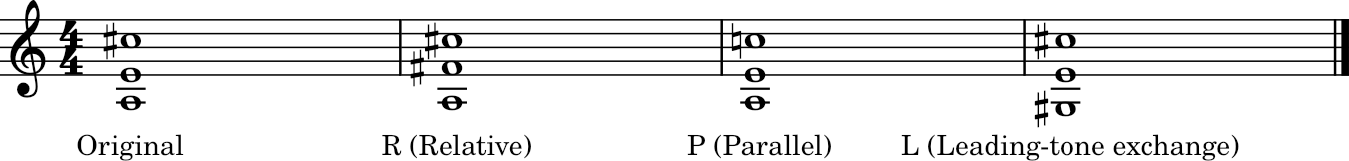

In [ ]:
# Create a stream
s = stream.Stream()

# Chords and their transformation labels
chords = [c, R_chord, P_chord, L_chord]
labels = ['Original', 'R (Relative)', 'P (Parallel)', 'L (Leading-tone exchange)']

for ch, label in zip(chords, labels):
    ch.duration.quarterLength = 4        # make each chord last 4 beats
    ch.lyric = label                     # add a label above the chord
    s.append(ch)

# Show the stream
s.show()

There are more transformations and functionality available in the neoRiemannian module in music21, if you are interested you might check out the full documentation [here](https://music21.org/music21docs/moduleReference/moduleAnalysisNeoRiemannian.html).